In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("12-health_risk_classification.csv")

In [3]:
df.head()

,bmi_score,blood_pressure_variation,activity_level_index,high_risk_flag
0,0.564223,0.652825,1.262925,1
1,-1.692569,2.981229,-0.180331,1
2,0.770383,0.400475,1.365806,1
3,2.135007,0.150832,3.084596,0
4,0.360342,1.026132,1.251574,1


In [4]:
df.describe()

,bmi_score,blood_pressure_variation,activity_level_index,high_risk_flag
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,-0.023702,0.016769,-0.020771,0.498000
std,1.203694,1.268761,1.392738,0.500246
min,-4.743951,-2.587178,-4.999018,0.000000
25%,-0.796655,-0.981320,-1.057938,0.000000
50%,0.142105,-0.317137,0.204506,0.000000
75%,0.956225,1.017388,1.061181,1.000000
max,2.321480,3.954873,3.477210,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   bmi_score                 1000 non-null   float64
 1   blood_pressure_variation  1000 non-null   float64
 2   activity_level_index      1000 non-null   float64
 3   high_risk_flag            1000 non-null   int64  
dtypes: float64(3), int64(1)
memory usage: 31.4 KB


In [6]:
df["high_risk_flag"].value_counts()

high_risk_flag
0    502
1    498
Name: count, dtype: int64

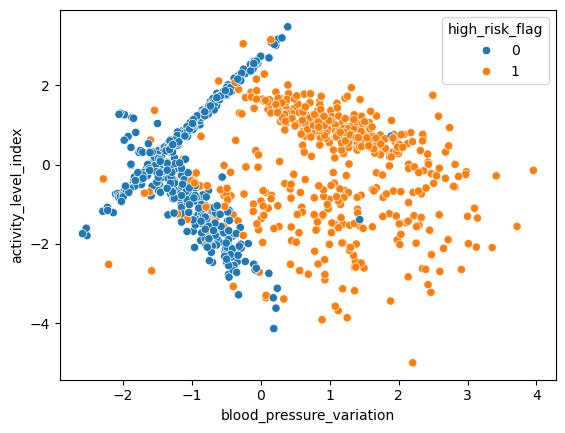

In [8]:
sns.scatterplot(x = df["blood_pressure_variation"], y= df["activity_level_index"], hue = df["high_risk_flag"]  )
plt.show()

In [9]:
X= df.drop("high_risk_flag", axis = 1)
y = df["high_risk_flag"]


In [14]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 15)

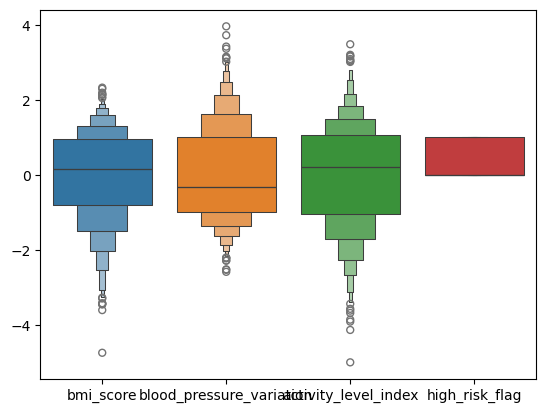

In [16]:
sns.boxenplot(df)
plt.show()

In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [20]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
from sklearn.neighbors import KNeighborsClassifier

In [84]:
classifier = KNeighborsClassifier(n_neighbors = 5, algorithm = "kd_tree" ,weights = "distance")

In [85]:
classifier.fit(X_train_scaled, y_train)

KNeighborsClassifier(algorithm='kd_tree', weights='distance')

In [86]:
y_pred = classifier.predict(X_test_scaled)

In [87]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [88]:
print("accuracy_score \n", accuracy_score(y_pred, y_test))
print("confusion matrix \n ", confusion_matrix(y_pred, y_test))
print("classification report \n", classification_report(y_pred, y_test))

accuracy_score 
 0.948
confusion matrix 
  [[123  10]
 [  3 114]]
classification report 
               precision    recall  f1-score   support

           0       0.98      0.92      0.95       133
           1       0.92      0.97      0.95       117

    accuracy                           0.95       250
   macro avg       0.95      0.95      0.95       250
weighted avg       0.95      0.95      0.95       250



In [73]:
classifier = KNeighborsClassifier(n_neighbors = 4, algorithm= "auto", weights = "uniform")

In [74]:
classifier.fit(X_train_scaled, y_train)
y_pred = classifier.predict(X_test_scaled)
print("accuracy_score \n", accuracy_score(y_pred, y_test))
print("confusion matrix \n ", confusion_matrix(y_pred, y_test))
print("classification report \n", classification_report(y_pred, y_test))

accuracy_score 
 0.956
confusion matrix 
  [[125  10]
 [  1 114]]
classification report 
               precision    recall  f1-score   support

           0       0.99      0.93      0.96       135
           1       0.92      0.99      0.95       115

    accuracy                           0.96       250
   macro avg       0.96      0.96      0.96       250
weighted avg       0.96      0.96      0.96       250



regression

In [89]:
df_reg = pd.read_csv("12-house_energy_regression.csv")

In [90]:
df_reg.head()

,avg_indoor_temp_change,outdoor_humidity_level,daily_energy_consumption_kwh
0,-0.167118,0.146714,-14.996950
1,-0.020902,0.117327,-12.678089
2,0.150419,0.364961,17.775455
3,0.555604,0.089581,6.661465
4,0.058209,-1.142970,-14.195530


In [91]:
df_reg.describe()

,avg_indoor_temp_change,outdoor_humidity_level,daily_energy_consumption_kwh
count,1000.000000,1000.000000,1000.000000
mean,0.033186,0.056982,1.766025
std,0.961603,1.014959,41.299085
min,-3.241267,-2.940389,-132.797922
25%,-0.611581,-0.651418,-25.600072
50%,0.036043,0.047742,1.065474
75%,0.648317,0.714886,28.766573
max,3.078881,3.852731,138.577662


In [92]:
df_reg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   avg_indoor_temp_change        1000 non-null   float64
 1   outdoor_humidity_level        1000 non-null   float64
 2   daily_energy_consumption_kwh  1000 non-null   float64
dtypes: float64(3)
memory usage: 23.6 KB


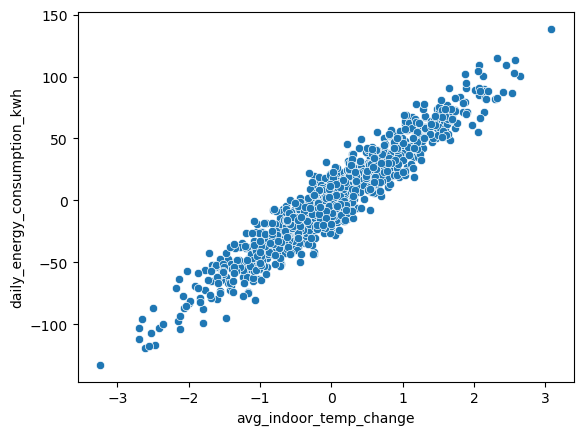

In [98]:
sns.scatterplot( x = df_reg["avg_indoor_temp_change"], y = df_reg["daily_energy_consumption_kwh"])
plt.show()

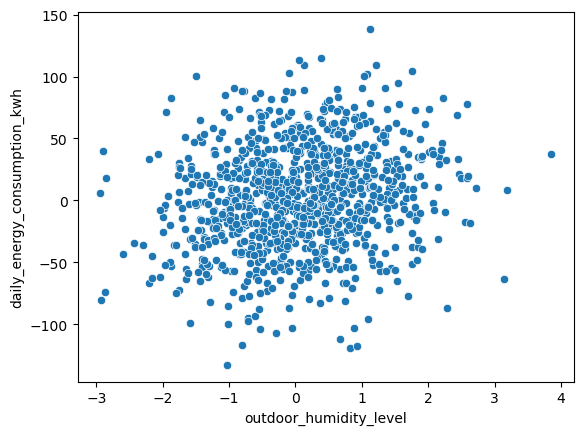

In [99]:
sns.scatterplot( x = df_reg["outdoor_humidity_level"], y = df_reg["daily_energy_consumption_kwh"])
plt.show()

In [100]:
df_reg.corr()

,avg_indoor_temp_change,outdoor_humidity_level,daily_energy_consumption_kwh
avg_indoor_temp_change,1.000000,0.002584,0.956682
outdoor_humidity_level,0.002584,1.000000,0.169557
daily_energy_consumption_kwh,0.956682,0.169557,1.000000


In [101]:
X = df_reg.drop("daily_energy_consumption_kwh", axis = 1)
y = df_reg['daily_energy_consumption_kwh']

In [102]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 15)

In [103]:
scaler = StandardScaler()

In [104]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [110]:
from sklearn.neighbors import KNeighborsRegressor

In [111]:
regressor = KNeighborsRegressor(n_neighbors = 4, algorithm = "auto")

In [113]:
regressor.fit(X_train_scaled, y_train)

KNeighborsRegressor(n_neighbors=4)

In [114]:
y_pred = regressor.predict(X_test_scaled)

In [117]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [119]:
print("r2 score :",  r2_score(y_test,y_pred))
print("mean absolute error: ", mean_absolute_error(y_test,y_pred))
print("mean squared error: ", mean_squared_error(y_test, y_pred))

r2 score : 0.9148138088251392
mean absolute error:  9.514825004784987
mean squared error:  141.46872240613325


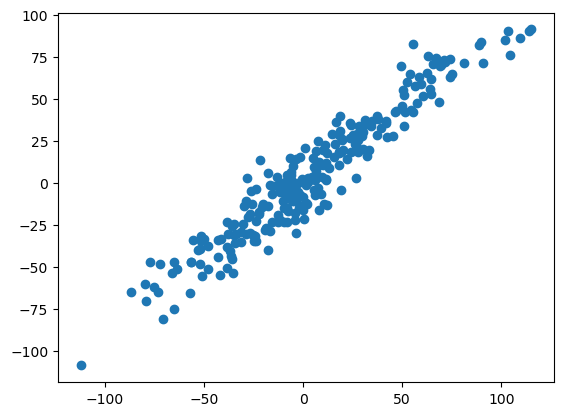

In [121]:
plt.scatter(y_test, y_pred)
plt.show()

In [130]:
regressor = KNeighborsRegressor(n_neighbors = 7, algorithm = "auto")

r2 score : 0.9189374253850693
mean absolute error:  9.326118628600977
mean squared error:  134.62063167240598


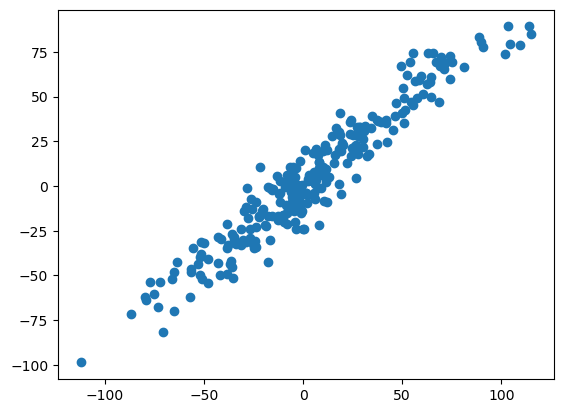

In [132]:
regressor.fit(X_train_scaled, y_train)
y_pred = regressor.predict(X_test_scaled)
print("r2 score :",  r2_score(y_test,y_pred))
print("mean absolute error: ", mean_absolute_error(y_test,y_pred))
print("mean squared error: ", mean_squared_error(y_test, y_pred))
plt.scatter(y_test, y_pred)
plt.show()